In [13]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet152V2 # High-capacity, state-of-the-art architecture [cite: 99]
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import cohen_kappa_score, confusion_matrix

# Define constants (Must match the preprocessing stage)
IMG_SIZE = 224
NUM_CLASSES = 5 # Stages 0 to 4
BATCH_SIZE = 16 # Adjust based on your GPU VRAM
BASE_PATH = 'preprocessed_data/' # !! ⚠️ UPDATE THIS PATH ⚠️ !!
PROCESSED_DATA_DIR = BASE_PATH # Assuming processed images are in the base path
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'train.csv') # Assuming your labels are here

In [14]:
# Load the master label file
df = pd.read_csv(TRAIN_CSV_PATH)

# Update the file paths to point to the PREPROCESSED images
df['file_path'] = df['id_code'].apply(
    lambda x: os.path.join(PROCESSED_DATA_DIR, 'train', f'{x}.png')
)
# Ensure the diagnosis is a string for the Keras FlowFromDataFrame
df['diagnosis'] = df['diagnosis'].astype('str') 

# Assuming your 'train' folder contains only training and validation data that needs 
# to be split based on the master CSV. If you already have separate label files 
# for train/valid, adjust this split accordingly.
# We will use this split to simulate your separate train/valid folders being mapped 
# to the master CSV.
# In a true pre-split scenario, you'd load separate CSVs/lists for train/valid.
train_df, valid_df = train_test_split(df, test_size=0.15, stratify=df['diagnosis'], random_state=42)

print(f"Total training samples: {len(train_df)}")
print(f"Total validation samples: {len(valid_df)}")

Total training samples: 2490
Total validation samples: 440


In [22]:
# Standard Keras data generator definition
# We use a custom function for augmentation and to ensure images are loaded correctly.
def create_generators(train_df, valid_df, batch_size, img_size):
    
    # Custom image loading function: Since images are preprocessed (0-255), 
    # we just need to load and normalize (0-1).
    def load_and_normalize_image(image):
        # Check if the input is already a NumPy array (loaded image)
        if isinstance(image, np.ndarray):
            # Normalize the image if it's already loaded
            return image.astype(np.float32) / 255.0  # Normalize pixel values to [0, 1]

        # If the input is not a NumPy array, assume it's a file path
        if not isinstance(image, str):
            raise TypeError(f"Expected image to be a string (file path) or NumPy array, but got {type(image)}")

        if not os.path.exists(image):
            raise FileNotFoundError(f"Image file not found: {image}")

        img = cv2.imread(image)
        if img is None:
            raise ValueError(f"Failed to read image file: {image}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Ensure RGB format
        return img.astype(np.float32) / 255.0 # Normalize pixel values to [0, 1] [cite: 55]
    
    # 1. Training Generator (with Geometric and Photometric Augmentation) 
    train_datagen = ImageDataGenerator(
        # Geometric Augmentations
        rotation_range=20, 
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True, 
        vertical_flip=True,
        # Photometric Augmentations
        brightness_range=[0.8, 1.2], # Simulate illumination variation [cite: 62]
        preprocessing_function=load_and_normalize_image
    )
    
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='file_path',
        y_col='diagnosis',
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )
    
    # 2. Validation Generator (No Augmentation)
    valid_datagen = ImageDataGenerator(
        preprocessing_function=load_and_normalize_image
    )
    
    valid_generator = valid_datagen.flow_from_dataframe(
        dataframe=valid_df,
        x_col='file_path',
        y_col='diagnosis',
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )
    
    return train_generator, valid_generator
train_generator, valid_generator = create_generators(train_df, valid_df, BATCH_SIZE, IMG_SIZE)

Found 2490 validated image filenames belonging to 5 classes.
Found 440 validated image filenames belonging to 5 classes.
Found 440 validated image filenames belonging to 5 classes.


In [23]:
def build_resnet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    
    # Initialize the base model (pre-trained on ImageNet)
    base_model = ResNet152V2(
        weights='imagenet',
        include_top=False, # We discard the classification layers
        input_shape=input_shape
    )
    
    # Strategy: Freeze the base model weights initially for stable training
    base_model.trainable = False 

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(), # Efficiently reduce feature maps to a single vector
        Dense(512, activation='relu'),
        Dropout(0.5), # Add dropout for regularization
        Dense(num_classes, activation='softmax')
    ])

    return model

# Instantiate and Compile
model = build_resnet_model()
model.compile(optimizer=Adam(learning_rate=1e-3), # Higher LR for the new top layers
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,383,301 (226.53 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

In [17]:
import cv2

In [24]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_dr_resnet_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait for 10 epochs after no improvement
    mode='min',
    verbose=1,
    restore_best_weights=True
)

# --- Stage 1: Train the Classification Head ---
print("\n--- Starting Stage 1: Training Classification Head ---")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // BATCH_SIZE,
    callbacks=[checkpoint, early_stopping]
)

# --- Stage 2: Fine-Tuning the Whole Model ---
print("\n--- Starting Stage 2: Fine-Tuning Entire ResNet ---")

# Unfreeze the base model
base_model = model.layers[0]
base_model.trainable = True

# Recompile with a very low learning rate
model.compile(optimizer=Adam(learning_rate=1e-5), # Critical for fine-tuning stability
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=50, # More epochs for full fine-tuning
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // BATCH_SIZE,
    callbacks=[checkpoint, early_stopping],
    initial_epoch=history.epoch[-1] # Start from where Stage 1 left off
)


--- Starting Stage 1: Training Classification Head ---


C:\Users\saksh\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6079 - loss: 1.2770
Epoch 1: val_loss improved from None to 0.70607, saving model to best_dr_resnet_model.keras

Epoch 1: val_loss improved from None to 0.70607, saving model to best_dr_resnet_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.6637 - loss: 0.9940 - val_accuracy: 0.7477 - val_loss: 0.7061
155/155 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.6637 - loss: 0.9940 - val_accuracy: 0.7477 - val_loss: 0.7061
Epoch 2/10
Epoch 2/10
  1/155 ━━━━━━━━━━━━━━━━━━━━ 5:11 2s/step - accuracy: 0.5625 - loss: 1.1820

C:\Users\saksh\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.70607 to 0.69415, saving model to best_dr_resnet_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 49s 308ms/step - accuracy: 0.5625 - loss: 1.1820 - val_accuracy: 0.7500 - val_loss: 0.6941
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 49s 308ms/step - accuracy: 0.5625 - loss: 1.1820 - val_accuracy: 0.7500 - val_loss: 0.6941
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6917 - loss: 0.8060
Epoch 3: val_loss improved from 0.69415 to 0.67906, saving model to best_dr_resnet_model.keras

Epoch 3: val_loss improved from 0.69415 to 0.67906, saving model to best_dr_resnet_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.7070 - loss: 0.7811 - val_accuracy: 0.7384 - val_loss: 0.6791
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.7070 - loss: 0.7811 - val_accuracy: 0.7384 - val_loss: 0.6791
Epoch 4/10
  1/155 ━━━━━━━━━━━━━━━━━━━━ 4:15 2s/step - accuracy: 0.6250 - loss: 0.8177
Epoch 4: val_loss improved from 0.67906 to 

KeyboardInterrupt: 

In [25]:
# Reload the best model weights before final evaluation
model.load_weights('best_dr_resnet_model.keras')

# Create a clean validation generator for final prediction
valid_generator_eval = create_generators(valid_df, valid_df, BATCH_SIZE, IMG_SIZE)[1] # Use the second generator (valid)
valid_generator_eval.reset()

print("\n--- Evaluating Model on Validation Set ---")

# 1. Prediction
Y_pred = model.predict(valid_generator_eval, steps=valid_generator_eval.samples // BATCH_SIZE + 1)
y_pred_classes = np.argmax(Y_pred, axis=1)

# Ensure true classes match the prediction length after generator batching
y_true_classes = valid_generator_eval.classes[:len(y_pred_classes)]

# 2. Key Metric: Quadratic Weighted Cohen's Kappa 
kappa = cohen_kappa_score(y_true_classes, y_pred_classes, weights='quadratic')
print(f"Quadratic Weighted Cohen's Kappa: {kappa:.4f}")

# 3. Standard Accuracy
loss, accuracy = model.evaluate(valid_generator_eval, steps=valid_generator_eval.samples // BATCH_SIZE)
print(f"Validation Accuracy: {accuracy:.4f}")

# 4. Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("\nConfusion Matrix (True vs. Predicted):\n", conf_matrix)

# TODO: Repeat evaluation on the separate 'test' subset once training is finalized.

C:\Users\saksh\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1034 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Found 440 validated image filenames belonging to 5 classes.
Found 440 validated image filenames belonging to 5 classes.
Found 440 validated image filenames belonging to 5 classes.

--- Evaluating Model on Validation Set ---

--- Evaluating Model on Validation Set ---


C:\Users\saksh\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step
Quadratic Weighted Cohen's Kappa: 0.8057
Quadratic Weighted Cohen's Kappa: 0.8057
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.7662 - loss: 0.6127
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.7662 - loss: 0.6127
Validation Accuracy: 0.7662

Confusion Matrix (True vs. Predicted):
 [[208   2   6   0   0]
 [  7  12  26   0   0]
 [  4   2 115   0   0]
 [  0   0  22   0   1]
 [  0   0  33   0   2]]
Validation Accuracy: 0.7662

Confusion Matrix (True vs. Predicted):
 [[208   2   6   0   0]
 [  7  12  26   0   0]
 [  4   2 115   0   0]
 [  0   0  22   0   1]
 [  0   0  33   0   2]]


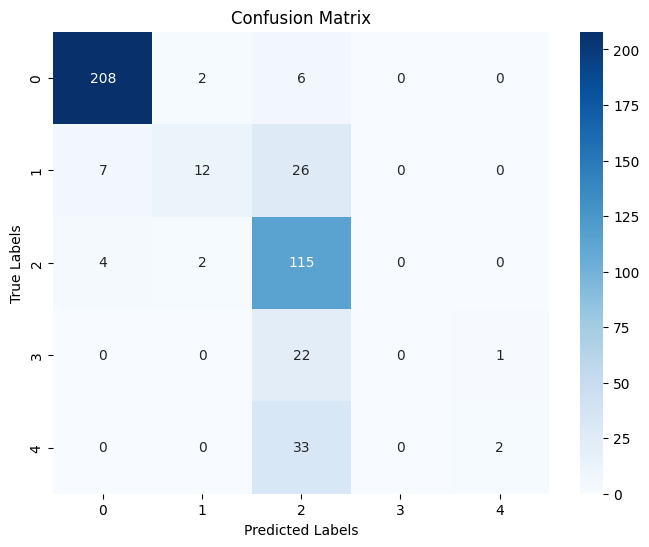

In [3]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Confusion matrix data
conf_matrix = np.array([
    [208, 2, 6, 0, 0],
    [7, 12, 26, 0, 0],
    [4, 2, 115, 0, 0],
    [0, 0, 22, 0, 1],
    [0, 0, 33, 0, 2]
])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
